# CPU vs GPU 데이터 분석 비교
- 데이터: scikit-learn 내장 캘리포니아 주택 데이터 (인터넷 최초 1회 다운로드 후 캐시됨)
- CPU: NumPy / GPU: PyTorch(CUDA)
- 각 셀에서 **Shift+Enter** 로 순서대로 실행하면 됨

> GPU 셀은 NVIDIA GPU + CUDA 버전 PyTorch가 설치돼 있어야 실제 GPU로 돌아감. 없으면 자동으로 CPU로 대체 실행되고 안내 메시지가 뜸.

In [1]:
import sys
print(sys.executable)


c:\Users\user\Desktop\강화학습\wh2026\Scripts\python.exe


In [2]:
# [셀 1] 라이브러리 (없으면 주석 풀고 설치)
# !pip install torch numpy pandas scikit-learn matplotlib

import time
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing

print("numpy:", np.__version__)

numpy: 2.5.1


a=0
a

In [3]:
# [셀 2] 내장 데이터 불러오기
data = fetch_california_housing(as_frame=True)
df = data.frame
print(df.shape)   # (20640, 9)
df.head()

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# [셀 3] CPU 기본 분석 - 기술통계 & 상관관계
print(df.describe().round(2))
print()
print("타깃(집값)과의 상관계수:")
print(df.corr()["MedHouseVal"].sort_values(ascending=False).round(3))

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1.80  
75%       37.71    -118.01         2.65  
max       41.95

In [5]:
# [셀 4] 무거운 연산용 데이터 준비
# 원본 2만 행은 GPU 차이를 보기엔 너무 작아서, 행을 복제해 크게 만듦
X_small = df.drop(columns="MedHouseVal").to_numpy(dtype=np.float32)

REPEAT = 50   # 메모리 부족하면 숫자를 줄이기 (예: 10)
X = np.tile(X_small, (REPEAT, 1))          # (약 103만 행, 8열)
print("연산용 행렬 크기:", X.shape)

연산용 행렬 크기: (1032000, 8)


In [6]:
# [셀 5] CPU 분석 - 표준화 + 공분산 행렬 + 고유값 분해(PCA 핵심 연산)
def analyze_cpu(X):
    Xs = (X - X.mean(axis=0)) / X.std(axis=0)      # 표준화
    print(Xs.T @ Xs)
    cov = (Xs.T @ Xs) / (len(Xs) - 1)              # 공분산 행렬
    eigvals, eigvecs = np.linalg.eigh(cov)         # 고유값 분해
    dist = Xs[:2000] @ Xs[:2000].T                 # 유사도 행렬 (일부만)
    return eigvals[::-1]

t0 = time.perf_counter()
eig_cpu = analyze_cpu(X)
cpu_time = time.perf_counter() - t0

print(f"CPU 시간: {cpu_time:.3f}초")
print("주성분별 설명 분산 비율:", (eig_cpu / eig_cpu.sum()).round(3))

[[ 1.03274000e+06 -1.22911109e+05  3.37669438e+05 -6.41238984e+04
   4.99269092e+03  1.94011855e+04 -8.23872969e+04 -1.55527744e+04]
 [-1.22911109e+05  1.03240125e+06 -1.58303219e+05 -8.03452656e+04
  -3.05896844e+05  1.36354072e+04  1.15331963e+04 -1.10831688e+05]
 [ 3.37669438e+05 -1.58303219e+05  1.03317456e+06  8.76275562e+05
  -7.45938438e+04 -5.01752441e+03  1.09848484e+05 -2.82304219e+04]
 [-6.41238984e+04 -8.03452656e+04  8.76275562e+05  1.03443525e+06
  -6.84215156e+04 -6.39556885e+03  7.20346094e+04  1.37157891e+04]
 [ 4.99269092e+03 -3.05896844e+05 -7.45938438e+04 -6.84215156e+04
   1.03276556e+06  7.22273203e+04 -1.12298789e+05  1.02257000e+05]
 [ 1.94011855e+04  1.36354072e+04 -5.01752441e+03 -6.39556885e+03
   7.22273203e+04  1.03492700e+06  2.44517578e+03  2.53933105e+03]
 [-8.23872969e+04  1.15331963e+04  1.09848484e+05  7.20346094e+04
  -1.12298789e+05  2.44517578e+03  1.03195006e+06 -9.45961375e+05]
 [-1.55527744e+04 -1.10831688e+05 -2.82304219e+04  1.37157891e+04
   

In [7]:
import torch
print(torch.__version__)


OSError: [WinError 4551] 애플리케이션 제어 정책에서 이 파일을 차단했습니다. Error loading "c:\Users\user\Desktop\강화학습\wh2026\Lib\site-packages\torch\lib\shm.dll" or one of its dependencies.

In [ ]:
# [셀 6] GPU 사용 가능 여부 확인
import torch


if torch.cuda.is_available():
    device = "cuda"
    print("GPU 사용 가능:", torch.cuda.get_device_name(0))
else:
    
    device = "cpu"
    print("CUDA GPU 없음 → 아래 GPU 셀은 CPU로 대체 실행됨")
    print("(NVIDIA GPU가 있다면 CUDA 버전 PyTorch 설치 필요: pytorch.org 참고)")

CUDA GPU 없음 → 아래 GPU 셀은 CPU로 대체 실행됨
(NVIDIA GPU가 있다면 CUDA 버전 PyTorch 설치 필요: pytorch.org 참고)


In [ ]:
# [셀 7] GPU 분석 - 같은 연산을 GPU에서
def analyze_gpu(X_np, device):
    X = torch.from_numpy(X_np).to(device)
    Xs = (X - X.mean(dim=0)) / X.std(dim=0)
    cov = (Xs.T @ Xs) / (len(Xs) - 1)
    eigvals, eigvecs = torch.linalg.eigh(cov)
    dist = Xs[:2000] @ Xs[:2000].T
    if device == "cuda":
        torch.cuda.synchronize()               # GPU 연산 끝날 때까지 대기 (시간 측정용)
    return eigvals.flip(0).cpu().numpy()

# 워밍업 1회 (GPU 첫 실행은 초기화 비용이 커서 측정에서 제외)
_ = analyze_gpu(X, device)

t0 = time.perf_counter()
eig_gpu = analyze_gpu(X, device)
gpu_time = time.perf_counter() - t0


print(f"GPU({device}) 시간: {gpu_time:.3f}초")

GPU(cpu) 시간: 0.028초


CPU : 0.078초
GPU : 0.029초  (device=cpu)
속도 배율: 2.7배
결과 일치 여부: True


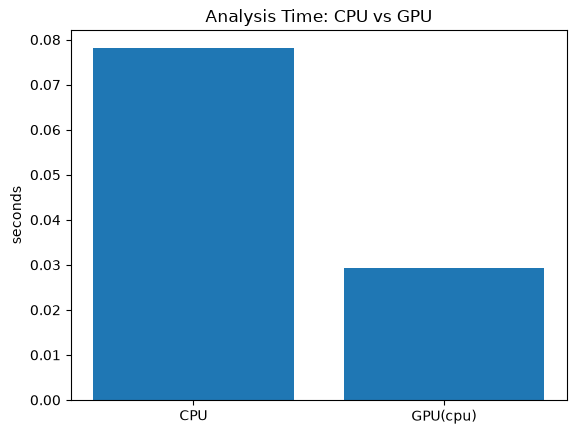

In [ ]:
# [셀 8] 결과 비교
import matplotlib.pyplot as plt

print(f"CPU : {cpu_time:.3f}초")
print(f"GPU : {gpu_time:.3f}초  (device={device})")
if gpu_time > 0:
    print(f"속도 배율: {cpu_time/gpu_time:.1f}배")
print("결과 일치 여부:", np.allclose(eig_cpu, eig_gpu, atol=1e-2))

plt.bar(["CPU", f"GPU({device})"], [cpu_time, gpu_time])
plt.ylabel("seconds")
plt.title("Analysis Time: CPU vs GPU")
plt.show()

In [ ]:
import matplotlib
import platform as plt

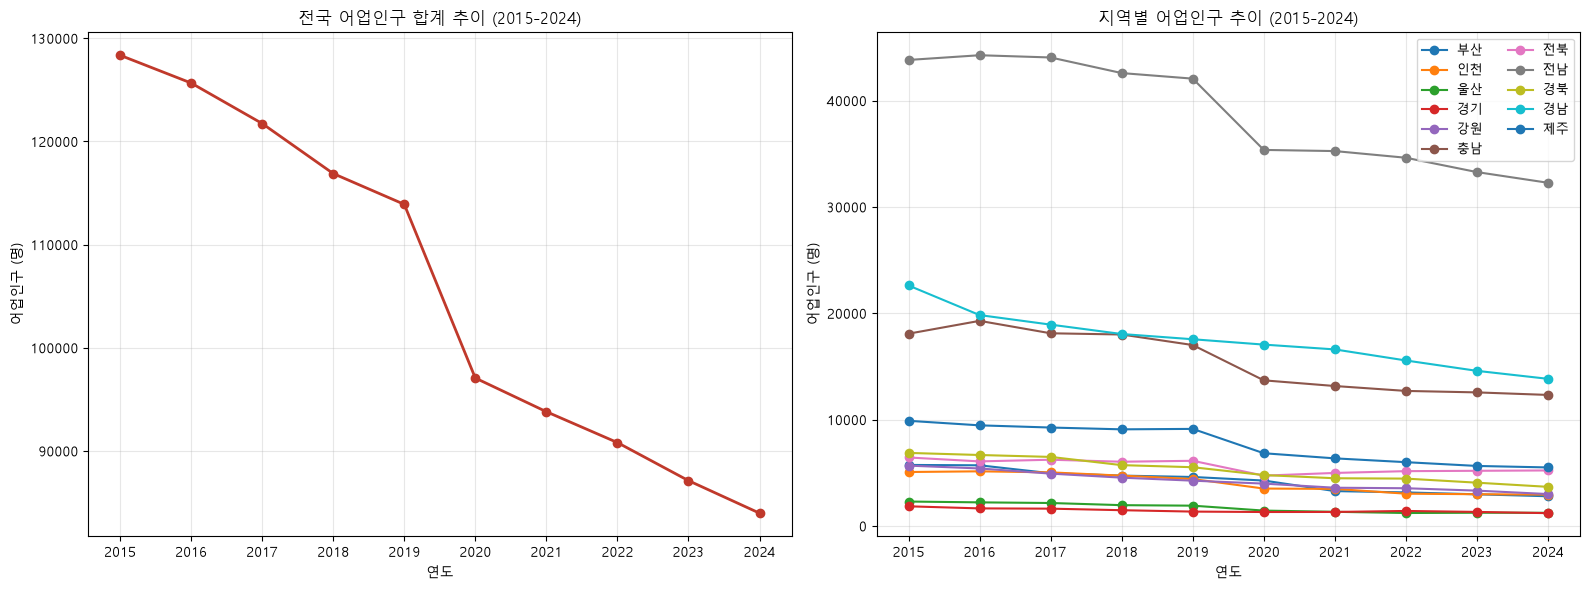

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
# 한글 폰트 설정 (Windows)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# CSV 로드
df = pd.read_csv(
    r"C:\Users\user\Downloads\연도별middot;지역별_어업인구_20260811215515.csv", encoding="utf-8-sig")
years = [str(y) for y in range(2015, 2025)]

total = df[df["지역별(2)"] == "소계"].iloc[0]
regions = df[df["지역별(2)"] != "소계"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 전국 합계 추이
ax0 = axes[0]
ax0.plot(years, total[years].astype(int), marker="o", color="#c0392b", linewidth=2)
ax0.set_title("전국 어업인구 합계 추이 (2015-2024)")
ax0.set_xlabel("연도")
ax0.set_ylabel("어업인구 (명)")
ax0.grid(alpha=0.3)

# 오른쪽: 지역별 추이
ax1 = axes[1]
for _, row in regions.iterrows():
    ax1.plot(years, row[years].astype(int), marker="o", label=row["지역별(2)"], linewidth=1.5)
ax1.set_title("지역별 어업인구 추이 (2015-2024)")
ax1.set_xlabel("연도")
ax1.set_ylabel("어업인구 (명)")
ax1.legend(loc="upper right", fontsize=9, ncol=2)
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("어업인구_추이.png", dpi=150)
plt.show()

In [ ]:
x, y = 100, 200
sum = x + y
print(x, "과", y, "의 합은", sum, "입니다.")
print("202602391최원혁")


100 과 200 의 합은 300 입니다.
202602391최원혁
